# Funciones de Activación en Redes Neuronales

Las funciones de activación permiten que una red neuronal **introduzca no linealidad** y aprenda relaciones complejas.  

Algunas funciones comunes son:

- **ReLU (Rectified Linear Unit)**  
- **Sigmoid**  
- **Tanh**  
- **Softmax**

---

## 1. Función Sigmoid

$\sigma(x) = \frac{1}{1 + e^{-x}}$

- Mapea cualquier número real a un valor entre **0 y 1**.  
- Se interpreta como **probabilidad** en problemas de clasificación binaria.  
- Su salida puede verse como:  
  - 0 → clase negativa  
  - 1 → clase positiva  

📌 **Uso típico**: última capa de un modelo de **clasificación binaria**.

---

## 2. Función Softmax

$Softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$

- Convierte un vector de valores en una distribución de probabilidades.  
- Cada salida está en el rango **0 a 1**.  
- La suma de todas las salidas es **1**.  
- Permite comparar **probabilidades entre múltiples clases**.

📌 **Uso típico**: última capa de un modelo de **clasificación multiclase** (ej: reconocer si una imagen es perro, gato o pájaro).

---

## 3. Diferencia entre Sigmoid y Softmax

- **Sigmoid**:  
  - Se aplica a **un solo valor**.  
  - Indica la probabilidad de pertenecer a la clase positiva.  
  - Usada en **clasificación binaria**.  

- **Softmax**:  
  - Se aplica a **un vector de valores (logits)**.  
  - Asigna una probabilidad a **cada clase posible**, sumando 1 en total.  
  - Usada en **clasificación multiclase**.

---

## 4. Analogía sencilla

- **Sigmoid**:  
  - Responde a una pregunta de "sí o no".  
  - Ejemplo: *¿Esta imagen contiene una manzana?* → 0.92 (sí), 0.08 (no).  

- **Softmax**:  
  - Responde a una pregunta de "¿cuál de estas opciones es?".  
  - Ejemplo: *¿Qué fruta aparece en la imagen?*  
    - Manzana: 0.70  
    - Naranja: 0.20  
    - Plátano: 0.10  

---

## 5. Ejemplos de aplicación

- **Sigmoid**  
  - Diagnóstico médico binario (enfermo vs sano).  
  - Detector de spam (spam vs no spam).  

- **Softmax**  
  - Reconocimiento de dígitos escritos (0–9).  
  - Clasificación de imágenes con múltiples categorías.  


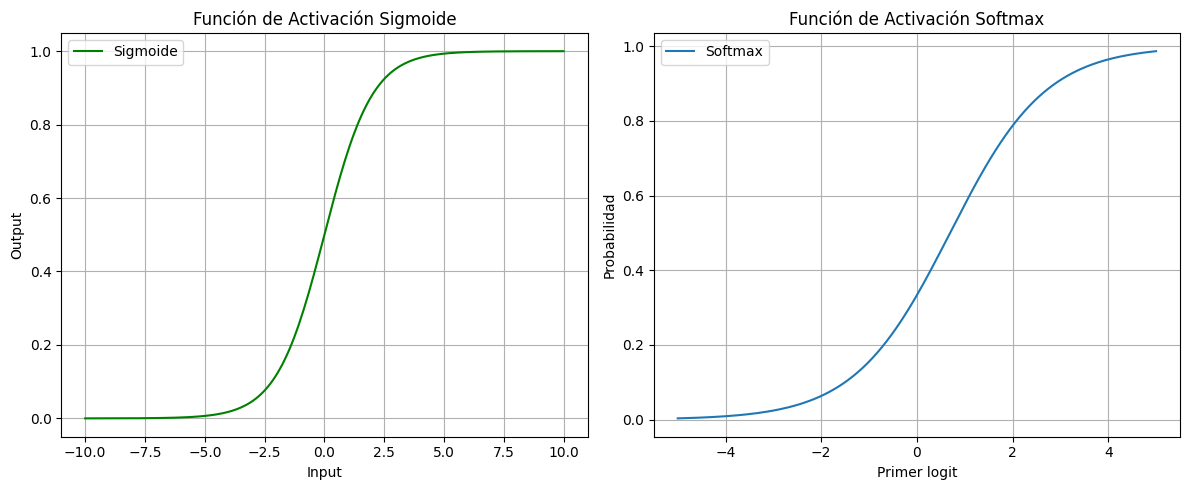

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax, expit as sigmoid  # expit = función sigmoide

# Para sigmoid: graficamos sobre un rango de valores
x = np.linspace(-10, 10, 200)
sigmoid_out = sigmoid(x)

# Para softmax: variamos el primer logit y dejamos los otros fijos
x_soft = np.linspace(-5, 5, 200)
softmax_out = np.array([softmax([xi, 0, 0]) for xi in x_soft])

plt.figure(figsize=(12, 5))

# Gráfica de la función sigmoide
plt.subplot(1, 2, 1)
plt.plot(x, sigmoid_out, label='Sigmoide', color='green')
plt.title('Función de Activación Sigmoide')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid()
plt.legend()

# Gráfica de la función softmax (probabilidad de cada clase)
plt.subplot(1, 2, 2)
plt.plot(x_soft, softmax_out[:, 0], label='Softmax')
plt.title('Función de Activación Softmax')
plt.xlabel('Primer logit')
plt.ylabel('Probabilidad')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from scipy.special import softmax, expit as sigmoid  # expit = función sigmoide

# Supongamos que la red neuronal calculó estas salidas (logits) antes de activación:
z = np.array([2.5, 0.3, -1.2])
o = np.array([1.45])

# Aplicamos softmax (para clasificación multiclase)
softmax_out = softmax(z)

# Aplicamos sigmoide (independiente en cada neurona)
sigmoid_out = sigmoid(o)

print("Logits:", z)
print("Softmax:", softmax_out, "→ suma:", np.sum(softmax_out))

print("Logits:", o)
print("Sigmoid:", sigmoid_out, "→ clase:", int(sigmoid_out[0] >= 0.5))


Logits: [ 2.5  0.3 -1.2]
Softmax: [0.88064861 0.09757865 0.02177274] → suma: 1.0
Logits: [1.45]
Sigmoid: [0.80999843] → clase: 1
